In [35]:
!pip -q install visualkeras pillow

import visualkeras
from PIL import Image

# if you already built `model`:
vk_img = visualkeras.layered_view(model, legend=True, scale_xy=2, scale_z=1, max_z=40)
display(vk_img)


ModuleNotFoundError: No module named 'visualkeras'

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

# optional diagram lib
try:
    import visualkeras
    from PIL import Image  # required by visualkeras
    HAS_VISUALKERAS = True
except Exception:
    HAS_VISUALKERAS = False
    print("visualkeras not available; the model diagram step will be skipped.")

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)


visualkeras not available; the model diagram step will be skipped.
TensorFlow: 2.18.0


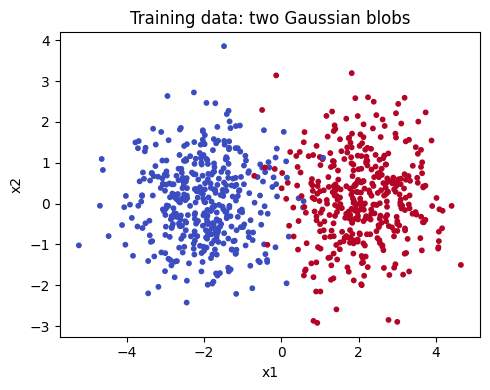

In [18]:
def make_blobs(n0=500, n1=500, offset=2.0, scale=1.0):
    c0 = np.random.randn(n0, 2) * scale + np.array([-offset, 0.0])
    c1 = np.random.randn(n1, 2) * scale + np.array([+offset, 0.0])
    X = np.vstack([c0, c1]).astype(np.float32)
    y = np.hstack([np.zeros(n0), np.ones(n1)]).astype(np.float32)
    return X, y

X, y = make_blobs()

perm = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, val_idx = perm[:split], perm[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

plt.figure(figsize=(5,4))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap="coolwarm")
plt.title("Training data: two Gaussian blobs")
plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()


In [19]:
def build_model():
    return models.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

model = build_model()
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
if HAS_VISUALKERAS:
    vk_img = visualkeras.layered_view(model, legend=True, scale_xy=2, scale_z=1, max_z=40)
    display(vk_img)
else:
    print("Skipping visualkeras diagram; install visualkeras if you want the image.")


Skipping visualkeras diagram; install visualkeras if you want the image.


In [21]:
bce = losses.BinaryCrossentropy()

xb = tf.convert_to_tensor(X_train[:64], dtype=tf.float32)
yb = tf.convert_to_tensor(y_train[:64], dtype=tf.float32)

pred = model(xb, training=True)
loss_value = bce(yb, pred)
print("Loss (before training):", float(loss_value))


Loss (before training): 0.8846225142478943


In [32]:
with tf.GradientTape() as tape:
    pred = model(xb, training=True)
    loss_value = bce(yb, pred)

grads = tape.gradient(loss_value, model.trainable_variables)
for v, g in zip(model.trainable_variables, grads):
    gnorm = float(tf.norm(g)) if g is not None else float('nan')
    print(f"{v.name:35s} shape={tuple(v.shape)}  grad_norm={gnorm:.4f}")


kernel                              shape=(2, 16)  grad_norm=0.0234
bias                                shape=(16,)  grad_norm=0.0285
kernel                              shape=(16, 16)  grad_norm=0.0188
bias                                shape=(16,)  grad_norm=0.0128
kernel                              shape=(16, 1)  grad_norm=0.0173
bias                                shape=(1,)  grad_norm=0.0040


In [29]:
lr = 0.05

with tf.GradientTape() as tape:
    pred = model(xb, training=True)
    loss_before = bce(yb, pred)
grads = tape.gradient(loss_before, model.trainable_variables)

for w, g in zip(model.trainable_variables, grads):
    w.assign_sub(lr * g)

loss_after = bce(yb, model(xb, training=True))
print("Loss before:", float(loss_before))
print("Loss after one SGD step:", float(loss_after))


Loss before: 0.8846225142478943
Loss after one SGD step: 0.8186311721801758


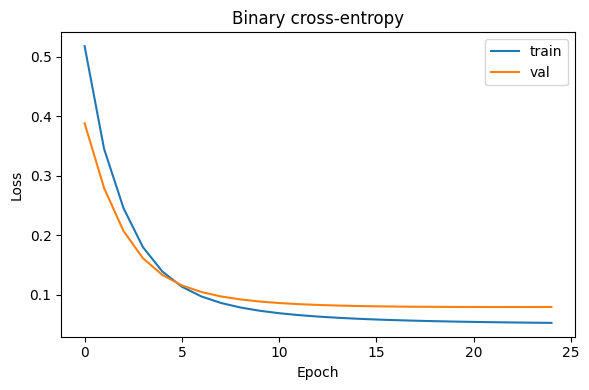

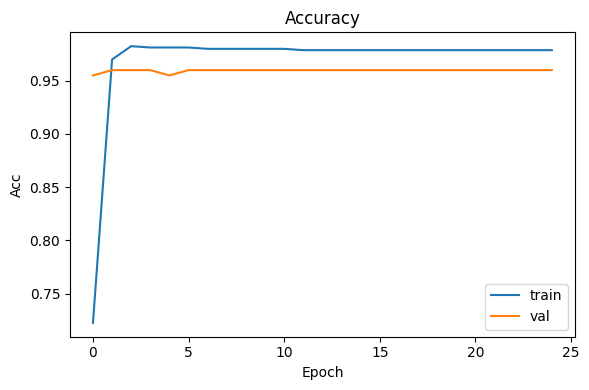

In [30]:
model = build_model()
opt = optimizers.SGD(learning_rate=0.05)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=25, batch_size=64, verbose=0)

plt.figure(figsize=(6,4))
plt.plot(hist.history['loss'], label='train')
plt.plot(hist.history['val_loss'], label='val')
plt.title('Binary cross-entropy'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc')
plt.legend(); plt.tight_layout(); plt.show()


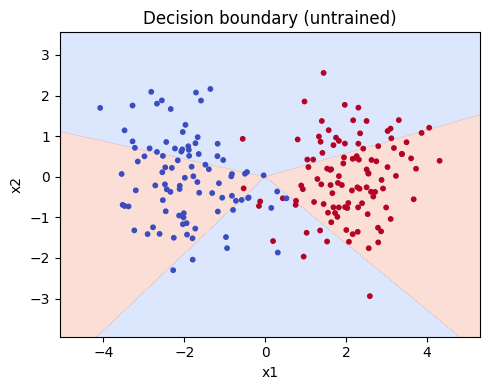

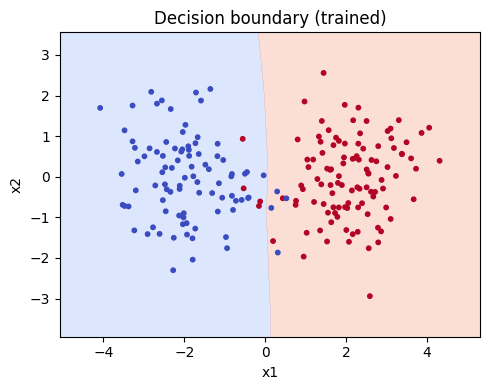

In [31]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    zz = model.predict(grid, verbose=0).reshape(xx.shape)
    plt.figure(figsize=(5,4))
    plt.contourf(xx, yy, zz, levels=[0,0.5,1], alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap="coolwarm")
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2")
    plt.tight_layout(); plt.show()

untrained = build_model()
plot_decision_boundary(untrained, X_val, y_val, "Decision boundary (untrained)")
plot_decision_boundary(model, X_val, y_val, "Decision boundary (trained)")
